In [13]:
import math
import pandas as pd
import numpy as np
import matplotlib as plot
from pathlib import Path

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

In [14]:
all_ratios_df = pd.read_excel("../Project 2/Data/All Ratios.xlsx", sheet_name="Ratios")


In [15]:
all_ratios_df

,Ticker,FY,Revenue,Gross profit,EBITDA,EBIT,Pretax Income,Net Income,Cash + Investments,Current Assets,Total Assets,Current Liabilities,Equity,Interest Expense,Operating Leases,Finance Leases,Total Debt,Adjusted Total Debt,D&A,CAPEX,Revenue Growth,Gross Margin,EBITDA Margin,Operating Margin,Pretax Margin,Effective Tax Rate,Net Profit Margin,ROE,ROIC,ROA,Quick Ratio,Current Ratio,Net Debt,Debt / Equity,Debt / Capital,Debt / Assets,Interest Coverage,Financial Leverage,CapEx / Revenue,PPE / Assets,Op Cash / Revenue,FCF Margin,Book Value Per Share
0,AMZN,2025-12-31,716924.00,360510.00,145731.00,79975.00,97311.00,77670.00,123029.00,229083.00,818042.00,218005.00,411065.00,2274,89252,12286,68851,170389,65756,-131819.00,0.12,0.50,0.20,0.11,0.14,0.20,0.11,0.19,0.18,0.09,0.84,1.05,-54178.00,0.17,0.14,0.08,35.17,1.99,0.18,0.76,0.19,0.01,38.31
1,AMZN,2024-12-31,637959.00,311671.00,121388.00,68593.00,68614.00,59248.00,101202.00,190867.00,624894.00,179431.00,285970.00,2406,79596,10602,57791,147989,52795,-82999.00,0.11,0.49,0.19,0.11,0.11,0.14,0.09,0.21,0.24,0.09,0.84,1.06,-43411.00,0.20,0.17,0.09,28.51,2.19,0.13,0.75,0.18,0.05,27.00
2,AMZN,2023-12-31,574785.00,270046.00,85515.00,36852.00,37557.00,30425.00,86780.00,172351.00,527854.00,164917.00,201875.00,3182,75639,12109,75823,163571,48663,-52729.00,0.12,0.47,0.15,0.06,0.07,0.19,0.05,0.15,0.16,0.06,0.81,1.05,-10957.00,0.38,0.27,0.14,11.58,2.61,0.09,0.75,0.15,0.06,19.44
3,AMZN,2022-12-31,513983.00,225152.00,38852.00,12248.00,-5936.00,-2722.00,70026.00,146791.00,462675.00,155393.00,146043.00,2367,69040,15783,76949,161772,41921,-63645.00,0.09,0.44,0.08,0.02,-0.01,0.54,-0.01,-0.02,0.04,-0.01,0.72,0.94,6923.00,0.53,0.35,0.17,5.17,3.17,0.12,0.76,0.09,-0.03,14.26
4,AMZN,2021-12-31,469822.00,197478.00,48291.00,24879.00,38151.00,33364.00,96049.00,161580.00,420549.00,142266.00,138245.00,1809,58330,23753,52769,134852,34433,-61053.00,0.22,0.42,0.10,0.05,0.08,0.13,0.07,0.24,0.23,0.08,0.90,1.14,-43280.00,0.38,0.28,0.13,13.75,3.04,0.13,0.70,0.10,-0.03,13.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,META,2011-12-31,3711.00,2851.00,2079.00,1756.00,1695.00,1000.00,3908.00,4604.00,6331.00,899.00,4899.00,42,945,677,0,1622,323,-606.00,0.88,0.77,0.56,0.47,0.46,0.41,0.27,0.20,1.05,0.16,4.96,5.12,-3908.00,0.00,0.00,0.00,41.81,1.29,0.16,0.30,0.42,0.25,2.29
75,META,2010-12-31,1974.00,1481.00,1171.00,1032.00,1008.00,606.00,1785.00,2246.00,2990.00,389.00,2162.00,22,0,0,0,0,139,-293.00,1.54,0.75,0.59,0.52,0.51,0.40,0.31,0.28,1.65,0.20,5.55,5.77,-1785.00,0.00,0.00,0.00,46.91,1.38,0.15,0.27,0.35,0.21,1.01
76,META,2009-12-31,777.00,554.00,340.00,262.00,254.00,122.00,633.00,633.00,1109.00,0.00,868.00,10,0,0,0,0,78,-33.00,1.86,0.71,0.44,0.34,0.33,0.52,0.16,0.14,0.54,0.11,NaN,NaN,-633.00,0.00,0.00,0.00,26.20,1.28,0.04,0.00,0.20,0.16,0.41
77,META,2008-12-31,272.00,148.00,NaN,-55.00,-56.00,-56.00,297.00,297.00,505.00,0.00,335.00,1,0,0,0,0,0,0.00,-0.20,0.54,0.00,-0.20,-0.21,0.00,-0.21,-0.17,-1.45,-0.11,NaN,NaN,-297.00,0.00,0.00,0.00,-55.00,1.51,NaN,NaN,-0.23,NaN,NaN


In [16]:
def plot_ratio_by_fy(all_ratios_df, column_name):
      """
      Plot one ratio column by fiscal year with one line per ticker.

      Example:
          plot_ratio_by_fy(all_ratios_df, "return_on_assets")
      """
      import matplotlib.pyplot as plt

      required_cols = ["FY", "Ticker", column_name]

      missing_cols = [col for col in required_cols if col not in all_ratios_df.columns]
      if missing_cols:
          raise ValueError(f"Missing columns: {missing_cols}")

      plot_df = all_ratios_df[required_cols].copy()

      plot_df["FY"] = pd.to_datetime(plot_df["FY"], errors="coerce")
      plot_df[column_name] = pd.to_numeric(plot_df[column_name], errors="coerce")

      plot_df = (
          plot_df
          .dropna(subset=["FY", "Ticker", column_name])
          .sort_values(["Ticker", "FY"])
      )

      colors = {
          "MSFT": "#7FBA00",
          "AMZN": "#F26920",
          "GOOG": "black",
          "META": "#0082FB"
      }

      fig, ax = plt.subplots(figsize=(10, 6))

      for ticker in ["MSFT", "AMZN", "GOOG", "META"]:
          company_df = plot_df[plot_df["Ticker"] == ticker]

          ax.plot(
              company_df["FY"],
              company_df[column_name],
              marker="o",
              linewidth=2,
              color=colors[ticker],
              label=ticker
          )

      y_label = column_name.replace("_", " ").title()

      ax.set_xlabel("Fiscal Year")
      ax.set_ylabel(y_label)
      ax.set_title(f"{y_label} by Fiscal Year")
      ax.grid(True, alpha=0.3)
      ax.legend(title="Company")

      fig.tight_layout()
      plt.show()

In [17]:
all_ratios_df.columns

Index(['Ticker', 'FY', 'Revenue', 'Gross profit', 'EBITDA', 'EBIT',
       'Pretax Income', 'Net Income', 'Cash + Investments', 'Current Assets',
       'Total Assets', 'Current Liabilities', 'Equity', 'Interest Expense',
       'Operating Leases', 'Finance Leases', 'Total Debt',
       'Adjusted Total Debt', 'D&A', 'CAPEX', 'Revenue Growth', 'Gross Margin',
       'EBITDA Margin', 'Operating Margin', 'Pretax Margin',
       'Effective Tax Rate', 'Net Profit Margin', 'ROE', 'ROIC', 'ROA',
       'Quick Ratio', 'Current Ratio', 'Net Debt', 'Debt / Equity',
       ' Debt / Capital', 'Debt / Assets', 'Interest Coverage',
       'Financial Leverage', 'CapEx / Revenue', 'PPE / Assets',
       'Op Cash / Revenue', 'FCF Margin', 'Book Value Per Share'],
      dtype='object')

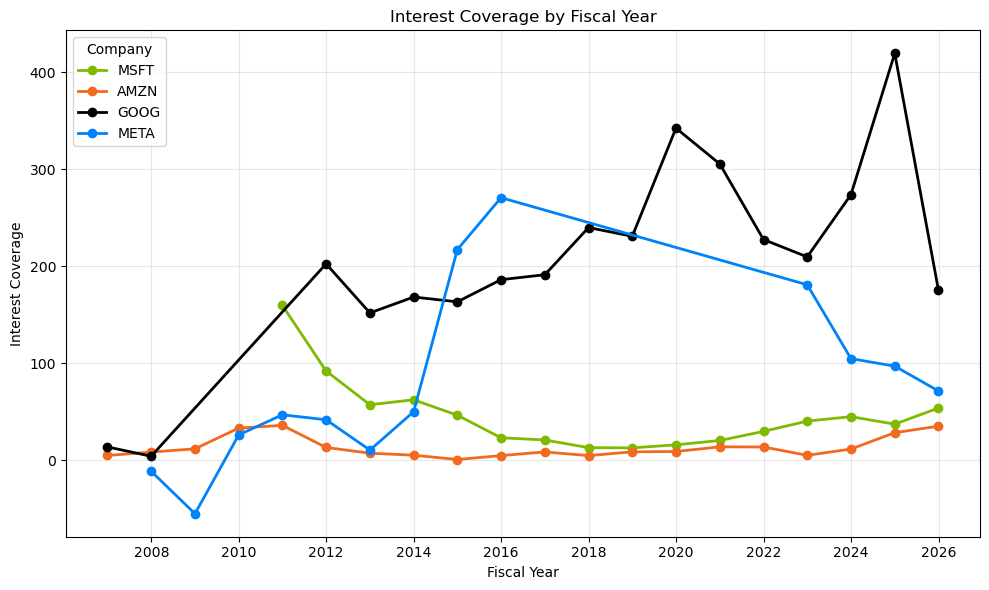

In [18]:
plot_ratio_by_fy(all_ratios_df, "Interest Coverage")
